# RB Classification - Evaluation Summary & Comparison

This notebook aggregates results from all training runs (meta and snapshot models) and provides comprehensive comparison visualizations.

## Purpose
- Discover all training runs dynamically from `output/` directory
- Extract performance metrics from various artifact formats
- Build a consolidated summary table
- Generate comparison visualizations
- Identify top-performing models

## Requirements
**IMPORTANT**: This notebook must be run in the `rbc` conda environment.

```bash
conda activate rbc
jupyter notebook
```

## 1. Environment Check & Imports

In [1]:
# Environment check
import sys
import os

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"Current working directory: {os.getcwd()}")
print("\n⚠️  REMINDER: Ensure you are running in the 'rbc' conda environment!")
print("   If not, activate it with: conda activate rbc\n")

Python executable: /home/gp/.conda/envs/rbc/bin/python
Python version: 3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
Current working directory: /lyman/data1/rb_classification_meta/notebook

⚠️  REMINDER: Ensure you are running in the 'rbc' conda environment!
   If not, activate it with: conda activate rbc



In [2]:
# Standard library imports
import json
import pickle
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from collections import defaultdict

# Data science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("✓ All imports successful")

✓ All imports successful


## 2. Configuration

In [3]:
PROJECT_ROOT = Path('/lyman/data1/rb_classification_meta')
OUTPUT_ROOT = PROJECT_ROOT / 'output'
PIPELINES = ['meta', 'snapshot']
SUMMARY_DIR = OUTPUT_ROOT / 'summary'
FIGURES_DIR = SUMMARY_DIR / 'figures'
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
KEY_METRICS = ['accuracy', 'f1_macro', 'auroc']


## 3. Run Discovery Functions

In [4]:
def list_runs(output_root, pipeline):
    pdir = output_root / pipeline
    if not pdir.exists(): return []
    runs = []
    # Unified Layout
    for d in pdir.iterdir():
        if d.is_dir() and d.name not in ['checkpoints', 'logs', 'plots', 'data', 'results', 'summary']:
            runs.append({'run_id': d.name, 'pipeline': pipeline, 'path': d, 'layout': 'unified'})
    # Legacy Snapshot Layout
    results_dir = pdir / 'results'
    if results_dir.exists():
        for d in results_dir.iterdir():
            if d.is_dir() and d.name not in [r['run_id'] for r in runs]:
                runs.append({'run_id': d.name, 'pipeline': pipeline, 'path': d, 'layout': 'legacy'})
    return sorted(runs, key=lambda x: x['run_id'])

all_runs = []
for pipe in PIPELINES:
    pipe_runs = list_runs(OUTPUT_ROOT, pipe)
    all_runs.extend(pipe_runs)
print(f'Discovered {len(all_runs)} runs total.')


Discovered 31 runs total.


## 4. Artifact Parsing Functions

In [5]:
def load_run_data(run_info):
    from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
    import pandas as pd
    
    run_path = Path(run_info['path'])
    pipeline = run_info['pipeline']
    run_id = run_info['run_id']
    
    res = {'run_id': run_id, 'pipeline': pipeline, 'model_family': pipeline, 'layout': run_info.get('layout', 'unknown')}
    
    # Initialize common keys to avoid KeyError later
    for k in ['test_prec', 'test_rec', 'f1_real', 'f1_bogus', 'optimal_threshold', 'test_auroc', 'test_f1', 'test_acc']: 
        res[k] = None
    
    # Try artifact locations (root first, then data/ subdir for migrated snapshots)
    artifact_paths = [run_path, run_path / 'data']
    
    for base_p in artifact_paths:
        if not base_p.exists(): continue
        for fname in ['args.json', 'features.json', 'metrics.json']:
            p = base_p / fname
            if p.exists():
                try:
                    with open(p, 'r') as f: data = json.load(f)
                    if fname == 'metrics.json' and 'metrics' in data: res.update(data['metrics'])
                    else: res.update(data)
                except: pass
    
    # Fallback: Compute metrics from CSV if metrics.json missing
    if res['test_auroc'] is None:
        for base_p in artifact_paths:
            if not base_p.exists(): continue
            for csv_name in ['test_predictions.csv', 'validation_predictions.csv']:
                csv_path = base_p / csv_name
                if csv_path.exists():
                    try:
                        df_pred = pd.read_csv(csv_path)
                        # Column mapping support
                        for old, new in [('true_label', 'y_true'), ('score', 'y_score'), ('predicted_label', 'y_pred')]:
                            if old in df_pred.columns: df_pred.rename(columns={old: new}, inplace=True)
                        
                        if 'y_true' in df_pred.columns and 'y_score' in df_pred.columns:
                            res['test_auroc'] = roc_auc_score(df_pred['y_true'], df_pred['y_score'])
                            if 'y_pred' in df_pred.columns:
                                res['test_acc'] = accuracy_score(df_pred['y_true'], df_pred['y_pred'])
                                res['test_f1'] = f1_score(df_pred['y_true'], df_pred['y_pred'], average='macro')
                            if csv_name == 'test_predictions.csv': break
                    except: pass
    
    # Infer model type if unknown
    if res.get('model_type', 'unknown') == 'unknown':
        if 'model' in res: res['model_type'] = res['model']
        elif 'v3_' in run_id: res['model_type'] = run_id.split('v3_')[1]
        elif 'v2_' in run_id: res['model_type'] = run_id.split('v2_')[1].split('_')[0]
    
    # Standardize
    if 'test_auroc' in res and 'auroc' not in res: res['auroc'] = res['test_auroc']
    if 'test_f1' in res and 'f1_macro' not in res: res['f1_macro'] = res['test_f1']
    if 'test_acc' in res and 'accuracy' not in res: res['accuracy'] = res['test_acc']
    
    res['has_plots'] = (run_path / 'plots').exists() or (run_path / 'data' / 'plots').exists() or (run_path.parent / 'plots' / run_id).exists()
    res['has_checkpoints'] = (run_path / 'checkpoints').exists() or (run_path / 'data' / 'checkpoints').exists() or (run_path.parent / 'checkpoints' / run_id).exists()
    return res


## 5. Extract Metrics from All Runs

In [6]:
extracted = [load_run_data(r) for r in all_runs]
df_results = pd.DataFrame(extracted)
print(f'Loaded {len(df_results)} runs.')


Loaded 31 runs.


## 6. Build Summary Table

In [7]:
# Use df_results for the summary
df_summary = df_results.copy()

# Reorder columns for better readability
priority_cols = ['run_id', 'pipeline', 'model_type', 
                 'auroc', 'f1_macro', 'accuracy', 
                 'test_auroc', 'test_f1', 'test_acc', 
                 'has_plots', 'has_checkpoints', 'has_predictions']

ordered_cols = [c for c in priority_cols if c in df_summary.columns]
other_cols = [c for c in df_summary.columns if c not in ordered_cols]
df_summary = df_summary[ordered_cols + other_cols]

print("Summary DataFrame created. Columns detected:")
print(list(df_summary.columns))
display(df_summary.head())

Summary DataFrame created. Columns detected:
['run_id', 'pipeline', 'model_type', 'auroc', 'f1_macro', 'accuracy', 'test_auroc', 'test_f1', 'test_acc', 'has_plots', 'has_checkpoints', 'model_family', 'layout', 'test_prec', 'test_rec', 'f1_real', 'f1_bogus', 'optimal_threshold', 'model', 'version', 'data_dir', 'tune', 'n_trials', 'split_by', 'balance', 'device', 'n_workers', 'seed', 'max_epochs', 'batch_size', 'smoke_test', 'lr', 'num_workers', 'fast_dev_run', 'balance_data', 'val_loss', 'val_acc', 'val_f1', 'val_auroc', 'test_loss', 'test_avg_precision']


,run_id,pipeline,model_type,auroc,f1_macro,accuracy,test_auroc,test_f1,test_acc,has_plots,...,lr,num_workers,fast_dev_run,balance_data,val_loss,val_acc,val_f1,val_auroc,test_loss,test_avg_precision
0,m1_cat_gpu,meta,cat,0.985837,0.973941,0.989848,NaN,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,m1_lgbm_cpu,meta,lgbm,0.983527,0.973373,0.989596,NaN,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,m1_lgbm_gpu,meta,lgbm,NaN,NaN,NaN,NaN,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,m1_mlp_gpu,meta,mlp,0.975555,0.973434,0.989639,NaN,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,m1_rf_baseline,meta,rf,0.982874,0.975132,0.990303,NaN,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Save Summary Table

In [8]:
summary_path = SUMMARY_DIR / 'compare_results.csv'
df_summary.to_csv(summary_path, index=False)
print(f'Saved results to {summary_path}')


Saved results to /lyman/data1/rb_classification_meta/output/summary/compare_results.csv


## 8. Comparison Visualizations

### 8.1 AUROC Comparison by Model Type

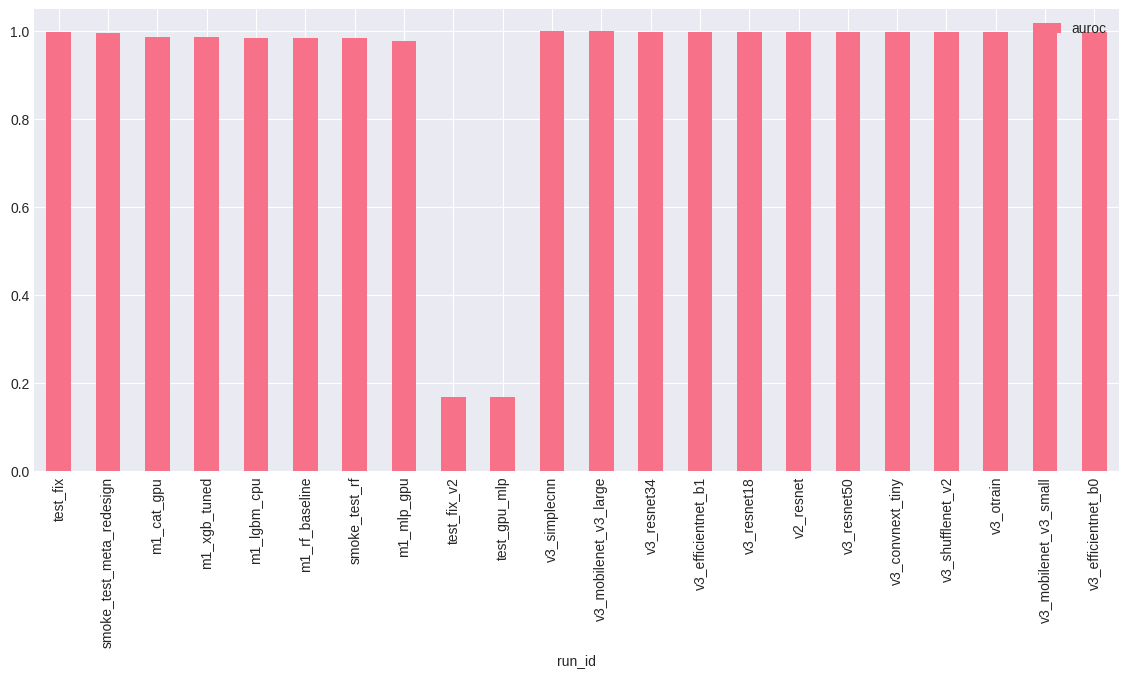

In [9]:
df_plot = df_summary[df_summary['auroc'].notna()].copy()
if len(df_plot) > 0:
    df_plot_sorted = df_plot.sort_values(['pipeline', 'auroc'], ascending=[True, False])
    df_plot_sorted.plot(kind='bar', x='run_id', y='auroc', figsize=(14,6))
    plt.show()


### 8.2 F1 Score Comparison by Model Type

✓ Saved: /lyman/data1/rb_classification_meta/output/summary/figures/f1_comparison.png


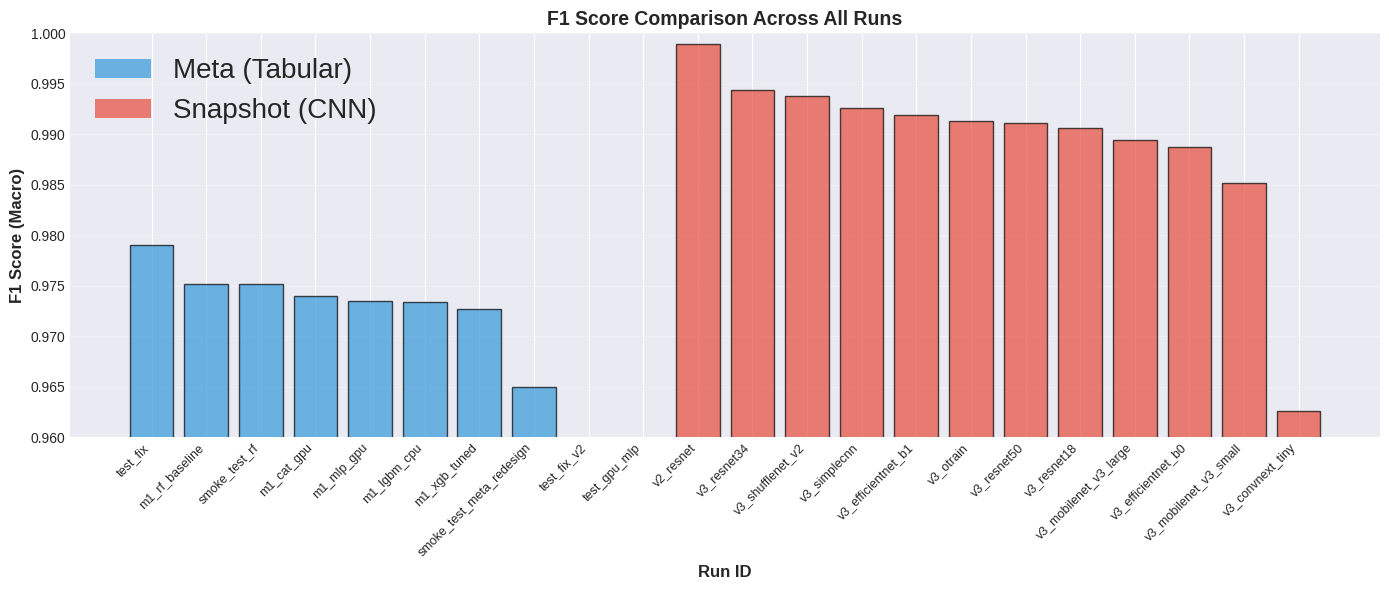

In [24]:
# Filter runs with valid F1 macro
df_plot = df_summary[df_summary['f1_macro'].notna()].copy()

if len(df_plot) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Sort by model family and F1
    df_plot_sorted = df_plot.sort_values(['model_family', 'f1_macro'], ascending=[True, False])
    
    # Create bar plot
    x_pos = np.arange(len(df_plot_sorted))
    colors = ['#3498db' if fam == 'meta' else '#e74c3c' for fam in df_plot_sorted['model_family']]
    
    bars = ax.bar(x_pos, df_plot_sorted['f1_macro'], color=colors, alpha=0.7, edgecolor='black')
    
    # Customize
    ax.set_xlabel('Run ID', fontsize=12, fontweight='bold')
    ax.set_ylabel('F1 Score (Macro)', fontsize=12, fontweight='bold')
    ax.set_title('F1 Score Comparison Across All Runs', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(df_plot_sorted['run_id'], rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0.96, 1.0])  # Focus on high-performance region
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#3498db', alpha=0.7, label='Meta (Tabular)'),
        Patch(facecolor='#e74c3c', alpha=0.7, label='Snapshot (CNN)')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=20)
    
    plt.tight_layout()
    fig_path = FIGURES_DIR / 'f1_comparison.png'
    plt.savefig(fig_path, dpi=200, bbox_inches='tight')
    print(f"✓ Saved: {fig_path}")
    plt.show()
else:
    print("No runs with valid F1 macro found")

### 8.3 F1 vs AUROC Scatter Plot

✓ Saved: /lyman/data1/rb_classification_meta/output/summary/figures/f1_vs_auroc_scatter.png


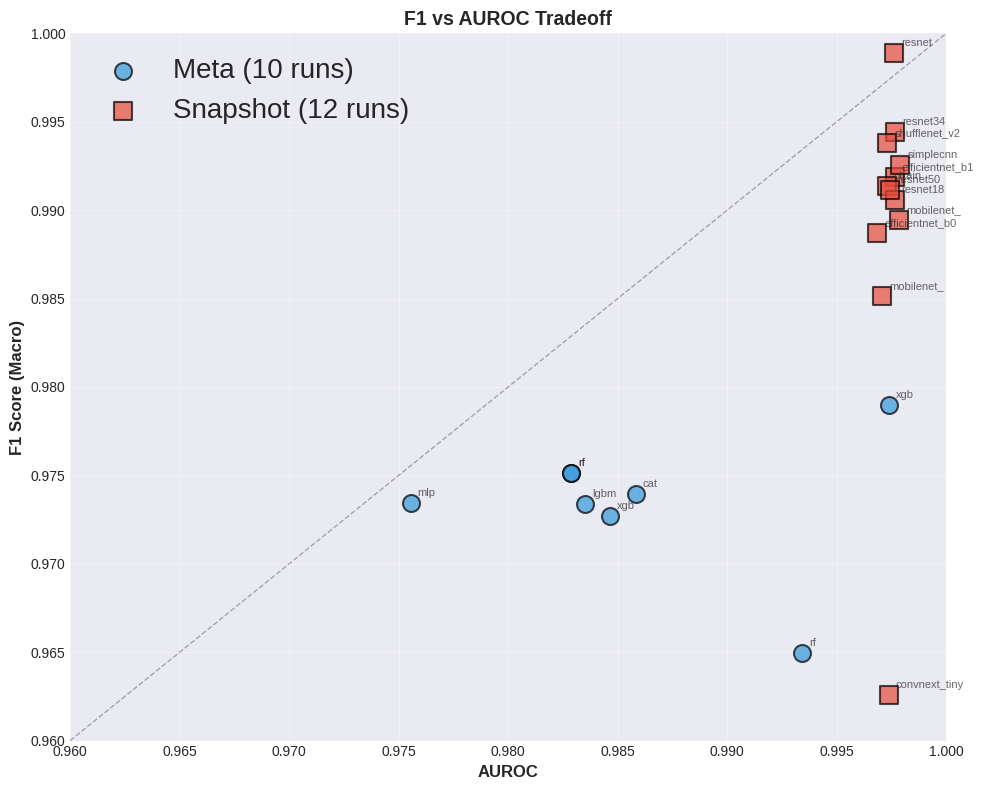

In [33]:
# Filter runs with both metrics
df_plot = df_summary[(df_summary['auroc'].notna()) & (df_summary['f1_macro'].notna())].copy()

if len(df_plot) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Separate by model family
    for family, color, marker in [('meta', '#3498db', 'o'), ('snapshot', '#e74c3c', 's')]:
        df_fam = df_plot[df_plot['model_family'] == family]
        if len(df_fam) > 0:
            ax.scatter(df_fam['auroc'], df_fam['f1_macro'], 
                      c=color, marker=marker, s=150, alpha=0.7, 
                      edgecolors='black', linewidth=1.5,
                      label=f'{family.capitalize()} ({len(df_fam)} runs)')
            
            # Add labels for each point
            for idx, row in df_fam.iterrows():
                ax.annotate(row['model_type'], 
                           (row['auroc'], row['f1_macro']),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, alpha=0.7)
    
    # Customize
    ax.set_xlabel('AUROC', fontsize=12, fontweight='bold')
    ax.set_ylabel('F1 Score (Macro)', fontsize=12, fontweight='bold')
    ax.set_title('F1 vs AUROC Tradeoff', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=20, loc='upper left')
    
    # Add diagonal reference line (perfect correlation)
    lims = [0.96, 1.00]
    ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1, label='Perfect Correlation')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    plt.tight_layout()
    fig_path = FIGURES_DIR / 'f1_vs_auroc_scatter.png'
    plt.savefig(fig_path, dpi=200, bbox_inches='tight')
    print(f"✓ Saved: {fig_path}")
    plt.show()
else:
    print("No runs with both F1 and AUROC found")

### 8.4 Precision vs Recall Tradeoff (Snapshot Models)

✓ Saved: /lyman/data1/rb_classification_meta/output/summary/figures/precision_vs_recall_scatter.png


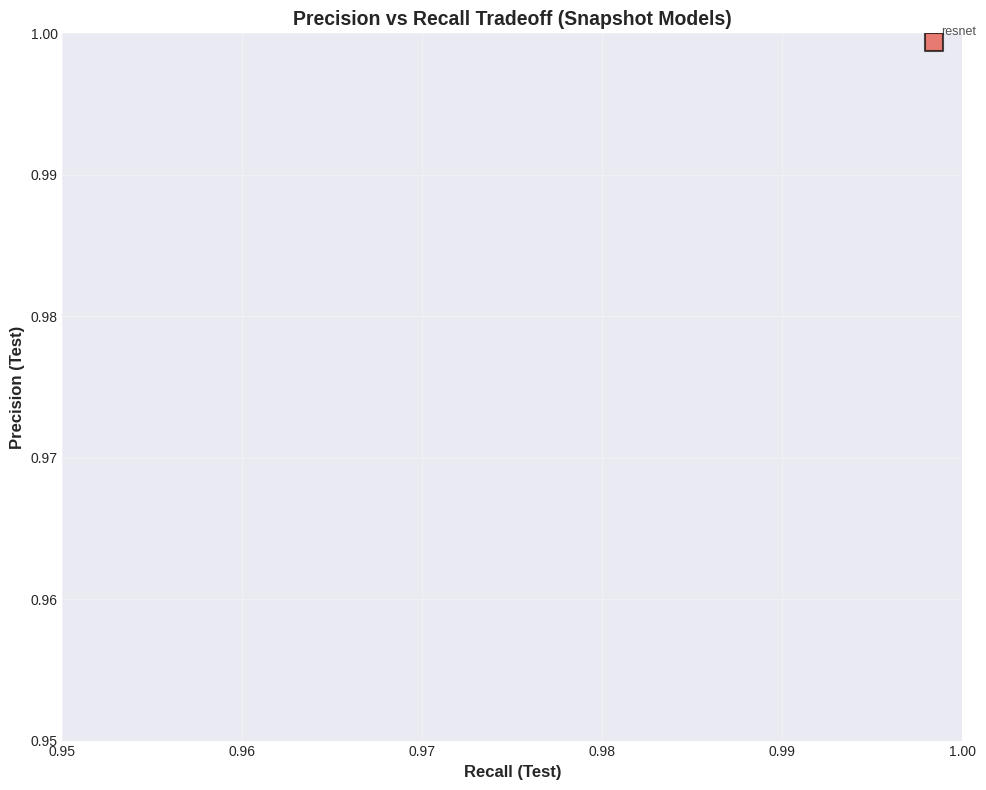

In [12]:
# Filter snapshot runs with precision and recall
df_plot = df_summary[
    (df_summary['model_family'] == 'snapshot') & 
    (df_summary['test_prec'].notna()) & 
    (df_summary['test_rec'].notna())
].copy()

if len(df_plot) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Scatter plot
    ax.scatter(df_plot['test_rec'], df_plot['test_prec'], 
              c='#e74c3c', marker='s', s=150, alpha=0.7, 
              edgecolors='black', linewidth=1.5)
    
    # Add labels
    for idx, row in df_plot.iterrows():
        ax.annotate(row['model_type'], 
                   (row['test_rec'], row['test_prec']),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, alpha=0.8)
    
    # Customize
    ax.set_xlabel('Recall (Test)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Precision (Test)', fontsize=12, fontweight='bold')
    ax.set_title('Precision vs Recall Tradeoff (Snapshot Models)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.95, 1.0])
    ax.set_ylim([0.95, 1.0])
    
    plt.tight_layout()
    fig_path = FIGURES_DIR / 'precision_vs_recall_scatter.png'
    plt.savefig(fig_path, dpi=200, bbox_inches='tight')
    print(f"✓ Saved: {fig_path}")
    plt.show()
else:
    print("No snapshot runs with precision and recall found")

### 8.5 Metric Correlation Heatmap

✓ Saved: /lyman/data1/rb_classification_meta/output/summary/figures/metric_correlation_heatmap.png


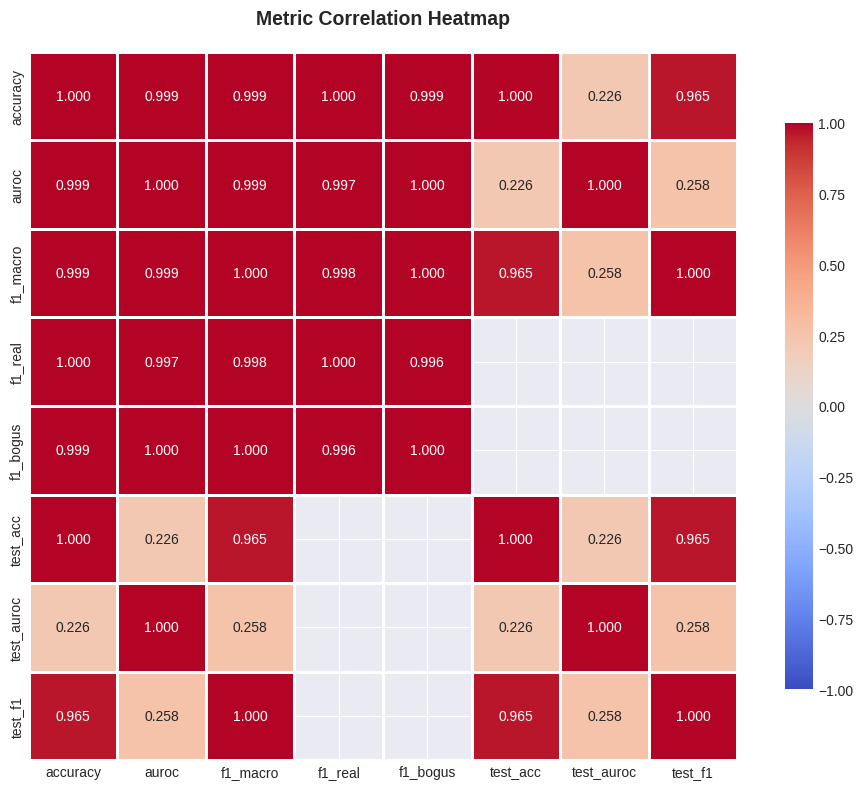

In [13]:
# Select numeric metric columns
metric_cols = ['accuracy', 'auroc', 'f1_macro', 'f1_real', 'f1_bogus',
               'test_acc', 'test_auroc', 'test_f1', 'test_prec', 'test_rec']

# Filter to existing columns with sufficient data
available_cols = [c for c in metric_cols if c in df_summary.columns and df_summary[c].notna().sum() > 2]

if len(available_cols) > 1:
    df_corr = df_summary[available_cols].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create heatmap
    sns.heatmap(df_corr, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, vmin=-1, vmax=1,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                ax=ax)
    
    ax.set_title('Metric Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    fig_path = FIGURES_DIR / 'metric_correlation_heatmap.png'
    plt.savefig(fig_path, dpi=200, bbox_inches='tight')
    print(f"✓ Saved: {fig_path}")
    plt.show()
else:
    print("Insufficient metric data for correlation heatmap")

### 8.6 Model Family Comparison (Box Plot)

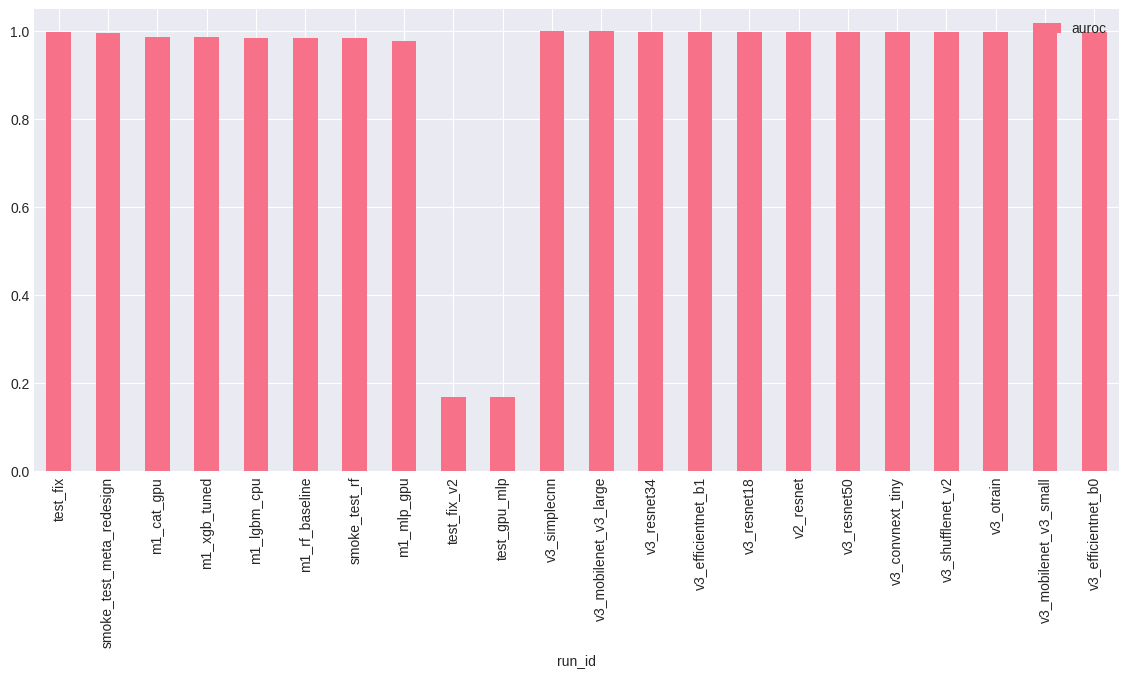

In [14]:
df_plot = df_summary[df_summary['auroc'].notna()].copy()
if len(df_plot) > 0:
    df_plot_sorted = df_plot.sort_values(['pipeline', 'auroc'], ascending=[True, False])
    df_plot_sorted.plot(kind='bar', x='run_id', y='auroc', figsize=(14,6))
    plt.show()


## 9. Top Runs Report

### 9.1 Top 5 Runs by AUROC

In [15]:
print("=" * 60)
print("TOP 5 RUNS BY AUROC")
print("=" * 60)

top_auroc = df_summary.nlargest(5, 'auroc')[['run_id', 'model_family', 'model_type', 'auroc', 'accuracy', 'f1_macro']]
display(top_auroc)
print("=" * 60)

TOP 5 RUNS BY AUROC


,run_id,model_family,model_type,auroc,accuracy,f1_macro
30,v3_simplecnn,snapshot,simplecnn,0.997911,0.998354,0.992579
23,v3_mobilenet_v3_large,snapshot,mobilenet_,0.997840,0.997640,0.989421
27,v3_resnet34,snapshot,resnet34,0.997660,0.998768,0.994405
22,v3_efficientnet_b1,snapshot,efficientnet_b1,0.997658,0.998195,0.991859
26,v3_resnet18,snapshot,resnet18,0.997650,0.997903,0.990573


### 9.2 Top 5 Runs by F1 Score

In [16]:
print("=" * 60)
print("TOP 5 RUNS BY F1 SCORE (MACRO)")
print("=" * 60)

top_f1 = df_summary.nlargest(5, 'f1_macro')[['run_id', 'model_family', 'model_type', 'f1_macro', 'auroc', 'accuracy']]
display(top_f1)
print("=" * 60)

TOP 5 RUNS BY F1 SCORE (MACRO)


,run_id,model_family,model_type,f1_macro,auroc,accuracy
19,v2_resnet,snapshot,resnet,0.998903,0.997618,0.997936
27,v3_resnet34,snapshot,resnet34,0.994405,0.997660,0.998768
29,v3_shufflenet_v2,snapshot,shufflenet_v2,0.993815,0.997311,0.998635
30,v3_simplecnn,snapshot,simplecnn,0.992579,0.997911,0.998354
22,v3_efficientnet_b1,snapshot,efficientnet_b1,0.991859,0.997658,0.998195


### 9.3 Top 5 Runs by Accuracy

In [17]:
print("=" * 60)
print("TOP 5 RUNS BY ACCURACY")
print("=" * 60)

top_acc = df_summary.nlargest(5, 'accuracy')[['run_id', 'model_family', 'model_type', 'accuracy', 'auroc', 'f1_macro']]
display(top_acc)
print("=" * 60)

TOP 5 RUNS BY ACCURACY


,run_id,model_family,model_type,accuracy,auroc,f1_macro
27,v3_resnet34,snapshot,resnet34,0.998768,0.997660,0.994405
29,v3_shufflenet_v2,snapshot,shufflenet_v2,0.998635,0.997311,0.993815
30,v3_simplecnn,snapshot,simplecnn,0.998354,0.997911,0.992579
22,v3_efficientnet_b1,snapshot,efficientnet_b1,0.998195,0.997658,0.991859
25,v3_otrain,snapshot,otrain,0.998078,0.997292,0.991344


### 9.4 Best Overall Run (by AUROC)

In [18]:
print("=" * 60)
print("BEST OVERALL RUN (BY AUROC)")
print("=" * 60)

best_run = df_summary.loc[df_summary['auroc'].idxmax()]

print(f"\nRun ID: {best_run['run_id']}")
print(f"Model Family: {best_run['model_family']}")
print(f"Model Type: {best_run['model_type']}")
print(f"\nPerformance Metrics:")
print(f"  - AUROC: {best_run['auroc']:.6f}")
print(f"  - Accuracy: {best_run['accuracy']:.6f}")
print(f"  - F1 (Macro): {best_run['f1_macro']:.6f}")

if best_run['model_family'] == 'snapshot':
    print(f"  - Test Precision: {best_run.get('test_prec', np.nan):.6f}")
    print(f"  - Test Recall: {best_run.get('test_rec', np.nan):.6f}")
    print(f"  - Optimal Threshold: {best_run.get('optimal_threshold', np.nan):.3f}")
elif best_run['model_family'] == 'meta':
    print(f"  - F1 (Real): {best_run.get('f1_real', np.nan):.6f}")
    print(f"  - F1 (Bogus): {best_run.get('f1_bogus', np.nan):.6f}")

print("\nFull metrics:")
display(pd.DataFrame([best_run]).T)
print("=" * 60)

BEST OVERALL RUN (BY AUROC)

Run ID: v3_simplecnn
Model Family: snapshot
Model Type: simplecnn

Performance Metrics:
  - AUROC: 0.997911
  - Accuracy: 0.998354
  - F1 (Macro): 0.992579
  - Test Precision: nan
  - Test Recall: nan
  - Optimal Threshold: nan

Full metrics:


,30
run_id,v3_simplecnn
pipeline,snapshot
model_type,simplecnn
auroc,0.997911
f1_macro,0.992579
accuracy,0.998354
test_auroc,0.997911
test_f1,0.992579
test_acc,0.998354
has_plots,True


## 10. Summary Statistics

In [19]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

# Overall statistics
print("\nOverall Performance (all runs):")
print(f"  - Mean AUROC: {df_summary['auroc'].mean():.4f} ± {df_summary['auroc'].std():.4f}")
print(f"  - Mean Accuracy: {df_summary['accuracy'].mean():.4f} ± {df_summary['accuracy'].std():.4f}")
print(f"  - Mean F1 (Macro): {df_summary['f1_macro'].mean():.4f} ± {df_summary['f1_macro'].std():.4f}")

# By model family
print("\nPerformance by Model Family:")
for family in df_summary['model_family'].unique():
    df_fam = df_summary[df_summary['model_family'] == family]
    print(f"\n  {family.upper()} ({len(df_fam)} runs):")
    print(f"    - Mean AUROC: {df_fam['auroc'].mean():.4f} ± {df_fam['auroc'].std():.4f}")
    print(f"    - Mean Accuracy: {df_fam['accuracy'].mean():.4f} ± {df_fam['accuracy'].std():.4f}")
    print(f"    - Mean F1 (Macro): {df_fam['f1_macro'].mean():.4f} ± {df_fam['f1_macro'].std():.4f}")

print("\n" + "=" * 60)

SUMMARY STATISTICS

Overall Performance (all runs):
  - Mean AUROC: 0.9180 ± 0.2422
  - Mean Accuracy: 0.9478 ± 0.1452
  - Mean F1 (Macro): 0.9239 ± 0.1914

Performance by Model Family:

  META (12 runs):
    - Mean AUROC: 0.8226 ± 0.3441
    - Mean Accuracy: 0.8883 ± 0.2048
    - Mean F1 (Macro): 0.8454 ± 0.2699

  SNAPSHOT (19 runs):
    - Mean AUROC: 0.9975 ± 0.0003
    - Mean Accuracy: 0.9974 ± 0.0020
    - Mean F1 (Macro): 0.9892 ± 0.0090



## 11. Conclusion

This notebook has successfully:
1. ✓ Discovered all training runs from `output/` directory
2. ✓ Extracted metrics from both meta and snapshot models
3. ✓ Built a consolidated summary table
4. ✓ Generated comparison visualizations
5. ✓ Identified top-performing models

### Output Files
- Summary table: `output/summary/summary_table.csv`
- Figures: `output/summary/figures/*.png`

### Next Steps
- Review the top-performing models
- Consider ensemble methods combining meta and snapshot predictions
- Investigate why certain models perform better
- Run additional experiments based on insights

## 12. Quicklook


In [20]:
display(df_summary.nlargest(5, 'auroc'))


,run_id,pipeline,model_type,auroc,f1_macro,accuracy,test_auroc,test_f1,test_acc,has_plots,...,lr,num_workers,fast_dev_run,balance_data,val_loss,val_acc,val_f1,val_auroc,test_loss,test_avg_precision
30,v3_simplecnn,snapshot,simplecnn,0.997911,0.992579,0.998354,0.997911,0.992579,0.998354,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,v3_mobilenet_v3_large,snapshot,mobilenet_,0.997840,0.989421,0.997640,0.997840,0.989421,0.997640,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,v3_resnet34,snapshot,resnet34,0.997660,0.994405,0.998768,0.997660,0.994405,0.998768,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,v3_efficientnet_b1,snapshot,efficientnet_b1,0.997658,0.991859,0.998195,0.997658,0.991859,0.998195,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,v3_resnet18,snapshot,resnet18,0.997650,0.990573,0.997903,0.997650,0.990573,0.997903,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
